# dim_red — load weighted HKS, subsample, cluster + reduce

Loads precomputed per-feature HKS weights (from `optimize_hks_weights.py`), applies
them, subsamples high-complexity organoids, clusters in the **weighted-HKS space**
(not chamfer), and embeds in 2D. No weight optimisation here.

In [490]:
import importlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import AgglomerativeClustering, KMeans
from sklearn.mixture import GaussianMixture
import umap

from src import utils
importlib.reload(utils)

<module 'src.utils' from '/Users/yuli/Documents/Code/SphericalHarmonics/src/utils.py'>

In [491]:
path = 'Data'
emb_dir = f"{path}/embeddings"

# --- load learned weights + metadata (from optimize_hks_weights.py) ---------
wf = np.load(f"{path}/hks_weights_full.npz", allow_pickle=True)
weights     = wf['weights']                 # (mode_cut, n_vocab)
mode_cut    = int(wf['mode_cut'])
trusted_ids = set(wf['trusted_ids'].astype(str))
print(f"weights {weights.shape} | mode_cut={mode_cut} | {len(trusted_ids)} trusted ids")

weights (8, 8) | mode_cut=8 | 405 trusted ids


In [492]:
# --- load data + build weighted-HKS shape features -------------------------
master = np.load(f"{path}/master.npz", allow_pickle=True)
filtered_ids      = master['ids'].astype(str)
filtered_datasets = master['datasets'].astype(str)
filtered_times    = master['times'].astype(str)
filtered_areas    = master['areas']
l_cross_values    = master['l_cross_values']

ids, hps = utils.load_power_spectrum(f"{path}/master.npz", mode_cut=mode_cut)
assert np.array_equal(ids, filtered_ids)
features = utils.apply_hks_weights(hps, weights)        # (N, mode_cut*n_vocab)
print('organoids:', len(filtered_ids), '| weighted features:', features.shape)

organoids: 3056 | weighted features: (3056, 64)


In [493]:
# --- fate-marker fractions (for colouring overlays) ------------------------
percentages, col_names = utils.load_fate_percentages(path, filtered_ids, filtered_datasets)
perc_fields = {f"perc_{n}": percentages[:, j] for j, n in enumerate(col_names)}
print('cell types:', col_names)

cell types: ['ABS', 'EC', 'EEPROG', 'PANETH', 'SECPROG', 'STEM', 'TA']


In [494]:
# --- optional: stratified subsample, cap per timepoint ----------------------
# Caps the number of organoids per timepoint (in sorted-timepoint order) before
# the high-complexity subset + clustering, so over-represented timepoints don't
# dominate. Set SUBSAMPLE_BY_TIME = False to keep everything.
SUBSAMPLE_BY_TIME = True
samples_per_timepoint = [50, 50, 50, 50, 100, 500, 500, 600]   # one cap per np.unique(filtered_times)

if SUBSAMPLE_BY_TIME:
    rng = np.random.default_rng(42)
    uniq_t = np.unique(filtered_times)
    assert len(samples_per_timepoint) == len(uniq_t), \
        f"need one cap per timepoint {list(uniq_t)} ({len(uniq_t)} of them)"
    keep_idx = np.sort(np.concatenate([
        rng.choice(np.where(filtered_times == t)[0],
                   size=min(samples_per_timepoint[i], int((filtered_times == t).sum())),
                   replace=False)
        for i, t in enumerate(uniq_t)]))
    filtered_ids      = filtered_ids[keep_idx]
    filtered_datasets = filtered_datasets[keep_idx]
    filtered_times    = filtered_times[keep_idx]
    filtered_areas    = filtered_areas[keep_idx]
    l_cross_values    = l_cross_values[keep_idx]
    features          = features[keep_idx]
    percentages       = percentages[keep_idx]
    perc_fields       = {k: v[keep_idx] for k, v in perc_fields.items()}
    print(f"subsampled to {len(keep_idx)} organoids")
    print(pd.Series(filtered_times).value_counts().sort_index().to_string())

subsampled to 1574 organoids
1p5          50
2            50
2p5          50
3            50
3p5         100
4           343
4p5         428
4p5-more    503


In [495]:
# --- subsample: high-complexity organoids ----------------------------------
complexity_mask = l_cross_values >= 0
shape_features  = features[complexity_mask]
m_ids = filtered_ids[complexity_mask]
print('subset:', shape_features.shape)

# --- cluster in the weighted-HKS space (NOT chamfer) -----------------------
# Ward merges nearest shapes bottom-up and allows uneven cluster sizes (gentler
# than KMeans's equal-size convex blobs). Switch CLUSTER_ALGO to try others.
n_shape_clusters = 10     # keep < 10
CLUSTER_ALGO     = 'kmeans'     # 'ward' | 'complete' | 'gmm' | 'kmeans'
if CLUSTER_ALGO == 'ward':
    shape_clusters = AgglomerativeClustering(n_shape_clusters, linkage='ward').fit_predict(shape_features)
elif CLUSTER_ALGO == 'complete':
    shape_clusters = AgglomerativeClustering(n_shape_clusters, linkage='complete').fit_predict(shape_features)
elif CLUSTER_ALGO == 'gmm':
    shape_clusters = GaussianMixture(n_shape_clusters, covariance_type='full',
                                     random_state=42, n_init=5).fit_predict(shape_features)
else:
    shape_clusters = KMeans(n_shape_clusters, random_state=42).fit_predict(shape_features)
# relabel by descending size so colours are stable (biggest = 0)
order = {c: r for r, c in enumerate(pd.Series(shape_clusters).value_counts().index)}
shape_clusters = np.array([order[c] for c in shape_clusters])
print(f"{CLUSTER_ALGO}: {n_shape_clusters} clusters | sizes "
      f"{pd.Series(shape_clusters).value_counts().sort_index().tolist()}")

subset: (1574, 64)
kmeans: 10 clusters | sizes [254, 219, 192, 172, 167, 135, 129, 115, 98, 93]


In [496]:
# --- 2D embedding + save (self-contained for inspect_embedding.py) ---------
method = 'umap'
if method == 'umap':
    hks_emb = umap.UMAP(n_components=2, random_state=42, n_neighbors=10, min_dist=0.5).fit_transform(shape_features)
elif method == 'pca':
    from sklearn.decomposition import PCA
    hks_emb = PCA(n_components=2).fit_transform(shape_features)

# per-point overlays: uid_group (0=none, g+1=group g) and trusted (weight-supervision set)
m_pos = {u: i for i, u in enumerate(m_ids)}
uid_group_field = np.zeros(len(m_ids))
for gi, grp in enumerate(utils.UID_GROUPS):
    for u in grp:
        if u in m_pos:
            uid_group_field[m_pos[u]] = gi + 1
trusted_field = np.array([1.0 if u in trusted_ids else 0.0 for u in m_ids])

utils.save_embedding(emb_dir, "hks_full_emb", hks_emb, m_ids, method,
                     times=filtered_times[complexity_mask], l_cross=l_cross_values[complexity_mask],
                     areas=filtered_areas[complexity_mask], shape_cluster=shape_clusters,
                     uid_group=uid_group_field, trusted=trusted_field,
                     **{k: v[complexity_mask] for k, v in perc_fields.items()})
print('saved', f"{emb_dir}/hks_full_emb.npz")

/opt/homebrew/anaconda3/envs/scmpx/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


saved Data/embeddings/hks_full_emb.npz


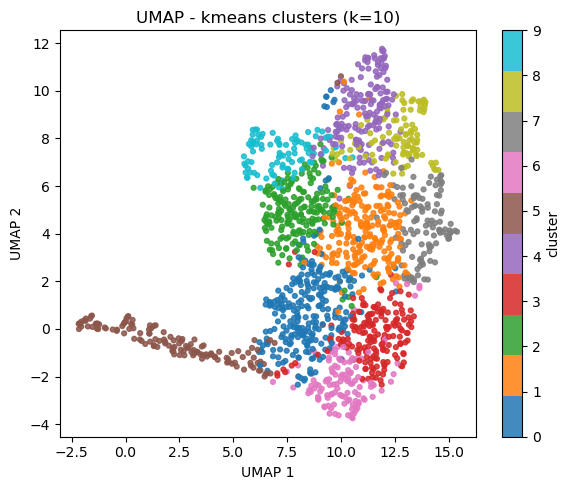

In [497]:
# --- embedding coloured by cluster -----------------------------------------
point_size = 12
fig, ax = plt.subplots(figsize=(6, 5))
sc = ax.scatter(hks_emb[:, 0], hks_emb[:, 1], c=shape_clusters, cmap='tab10', s=point_size, alpha=0.85)
ax.set_title(f'{method.upper()} - {CLUSTER_ALGO} clusters (k={n_shape_clusters})')
ax.set_xlabel(f'{method.upper()} 1'); ax.set_ylabel(f'{method.upper()} 2')
fig.colorbar(sc, ax=ax, ticks=range(n_shape_clusters), label='cluster')
plt.tight_layout(); plt.show()

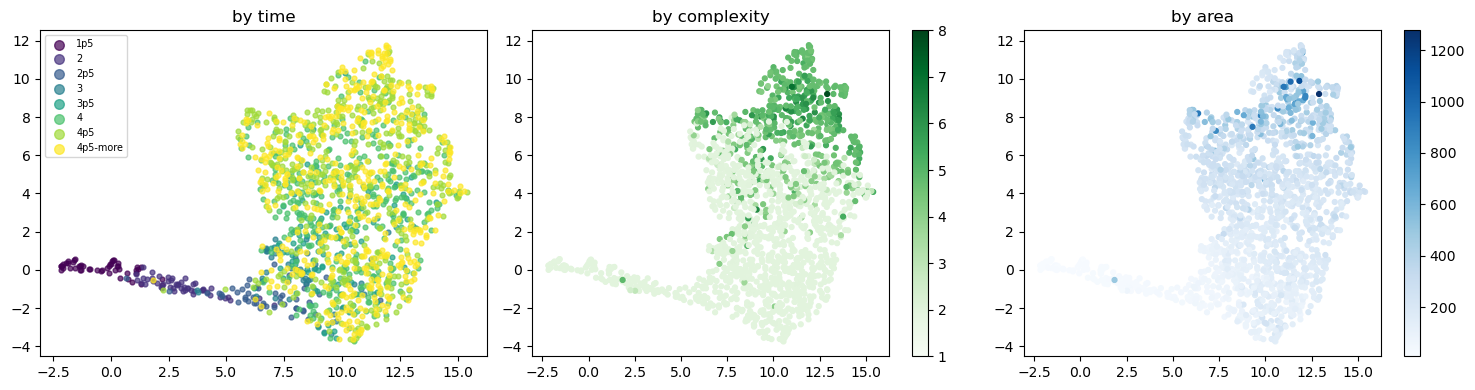

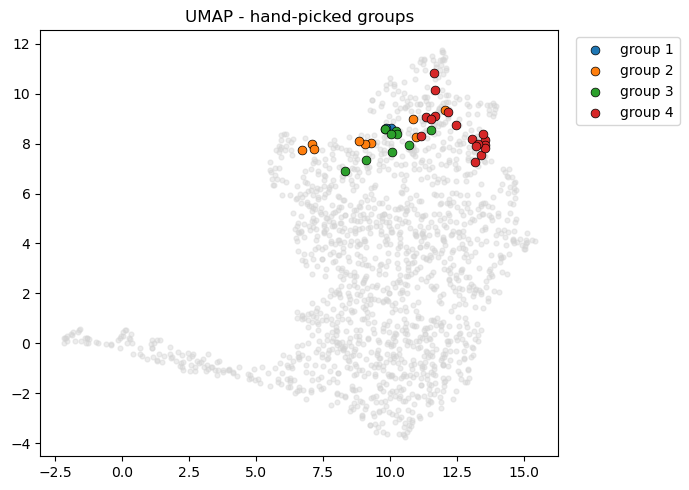

In [498]:
# --- embedding by time / complexity / area, and hand-picked groups ---------
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
tt = filtered_times[complexity_mask]; uniq_t = np.unique(tt); cmap_t = plt.get_cmap('viridis')
for i, t in enumerate(uniq_t):
    mk = tt == t
    axes[0].scatter(hks_emb[mk, 0], hks_emb[mk, 1], color=cmap_t(i / max(1, len(uniq_t) - 1)),
                    s=point_size, alpha=0.7, label=t)
axes[0].set_title('by time'); axes[0].legend(markerscale=2, fontsize=7)
sc = axes[1].scatter(hks_emb[:, 0], hks_emb[:, 1], c=l_cross_values[complexity_mask], cmap='Greens', s=point_size, vmin=1, vmax=8)
axes[1].set_title('by complexity'); fig.colorbar(sc, ax=axes[1])
sc = axes[2].scatter(hks_emb[:, 0], hks_emb[:, 1], c=filtered_areas[complexity_mask], cmap='Blues', s=point_size)
axes[2].set_title('by area'); fig.colorbar(sc, ax=axes[2])
plt.tight_layout(); plt.show()

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(hks_emb[:, 0], hks_emb[:, 1], color='lightgrey', s=point_size, alpha=0.4)
for gi, grp in enumerate(utils.UID_GROUPS):
    mk = np.isin(m_ids, grp)
    if mk.any():
        ax.scatter(hks_emb[mk, 0], hks_emb[mk, 1], color=plt.get_cmap('tab10')(gi), s=40,
                   edgecolors='black', linewidths=0.5, label=f'group {gi + 1}')
ax.set_title(f'{method.upper()} - hand-picked groups'); ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout(); plt.show()